In [1]:
from neuromodes.eigen import EigenSolver, project_emodes
from neuromodes.io import fetch_surf, fetch_map
from lapy.plot import plot_tet_mesh
from nilearn.plotting import plot_stat_map
import matplotlib.pyplot as plt
import numpy as np

# Set path to lh hippocampus nifti
nifti = 'C:/Users/ipop0003/neuromodes/neuromodes/data/hcp_hippo-lh_thr25.nii.gz'

# Solve for eigenmodes
solver = EigenSolver(nifti).solve(100, seed=0, lump=True)

TetMesh with regular Laplace


In [2]:
# Verify lumping
print(np.allclose(solver.mass.todense(), np.diag(solver.mass.diagonal())))

True


In [3]:
# Visualise mode 2
plot_tet_mesh(solver.geometry, vfunc=solver.emodes[:, 1], plot_edges=True)

Mesh is oriented, nothing to do
Found 2056 triangles on boundary.


Number of NaNs: 753
Number of Infs: 0


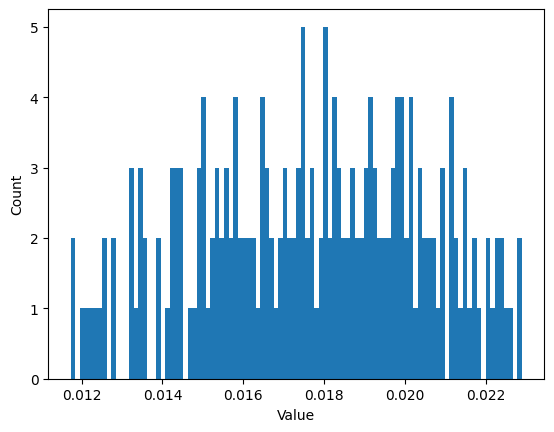

In [4]:
# project eigenmodes into volume space
emodes_vox = project_emodes(nifti, solver.emodes[:, [1]], solver.geometry)

# check for nans and infs within mask
data = emodes_vox.get_fdata()
data = data[data != 0]
print('Number of NaNs:', np.isnan(data).sum())
print('Number of Infs:', np.isinf(data).sum())

# Plot distribution
plt.hist(data.flatten(), bins=100)
plt.xlabel('Value')
plt.ylabel('Count')
plt.show()

C:\Users\ipop0003\AppData\Local\Temp\ipykernel_26636\3378822025.py:1: UserWarning:

Non-finite values detected. These values will be replaced with zeros.



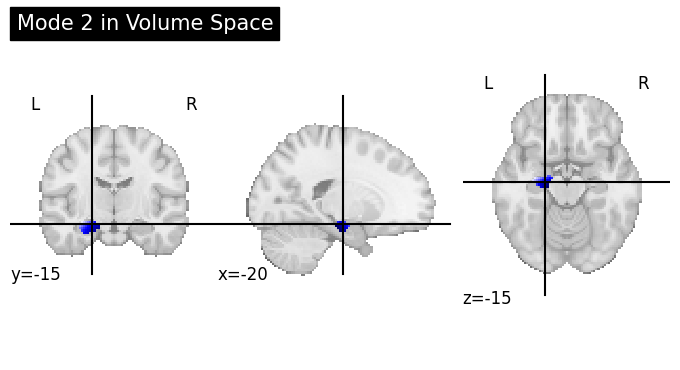

In [5]:
plot_stat_map(emodes_vox, cut_coords=(-20, -15, -15), title='Mode 2 in Volume Space', cmap='seismic_r', draw_cross=True, colorbar=False)

Though some shouldn't be used with the hippocampus, all the wrapper methods work:

In [6]:
hippogem = solver.model_connectome(k=solver.n_modes)

In [7]:
hippowaves = solver.simulate_waves()

In [8]:
fc_recon, fc_recon_error, recon, recon_error, beta = solver.reconstruct_timeseries(hippowaves[:, 990:])


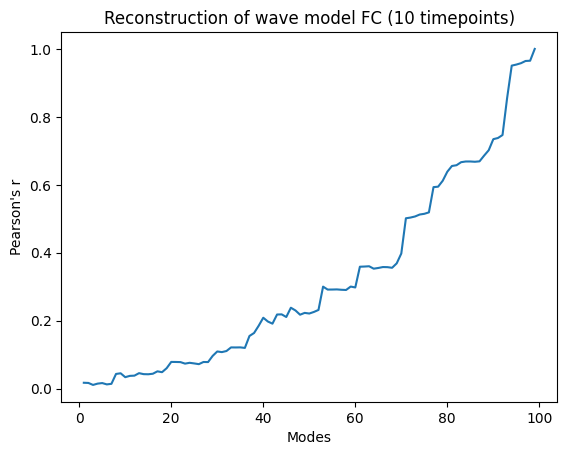

In [9]:
# plot recon_error
plt.plot(1-fc_recon_error)
plt.xlabel('Modes')
plt.ylabel('Pearson\'s r')
plt.title('Reconstruction of wave model FC (10 timepoints)')
plt.show()

In [10]:
# Verify that our firstborn still works
mesh, medmask = fetch_surf()
myelinmap = fetch_map('myelinmap')

solver = EigenSolver(mesh, mask=medmask, hetero=myelinmap).solve(100, seed=0, lump=True)
waves = solver.simulate_waves()